# Building a Research Report Generator with LangGraph

In this notebook we'll build a **multi-agent research report pipeline** that generates professional reports with text, data tables, charts, and web screenshots.

Along the way we'll learn every core LangGraph concept:

1. **State Design** — TypedDict with reducers (`Annotated` + `operator.add`)
2. **Structured Output** — Pydantic models + `with_structured_output()`
3. **Conditional Routing** — `add_conditional_edges()` with loop-back
4. **Parallel Execution** — Fan-out from one node to multiple downstream nodes
5. **Tool Integration** — Web search with Tavily
6. **Pure Python Nodes** — Chart generation without any LLM call
7. **Quality Loops** — Self-review → multi-destination re-routing

Official docs: https://docs.langchain.com/oss/python/langgraph/

In [33]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain-openai langchain-anthropic langchain-core \
    langchain-tavily tavily-python matplotlib seaborn pandas jinja2 pydantic \
    python-dotenv

In [34]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")
_set_env("TAVILY_API_KEY")

---
## 1. State Design: TypedDict + Reducers

The **state** is the data structure that flows through the graph. Every node reads from it and returns updates.

### The Override Problem

By default, returning a value for a key **overwrites** the previous value. This is fine for single values, but when multiple nodes contribute to a list (like search results), we lose data!

In [35]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

# Problem: list gets overwritten!
class BadState(TypedDict):
    items: list[str]

def node_a(state):
    return {"items": ["from_a"]}

def node_b(state):
    return {"items": ["from_b"]}

g = StateGraph(BadState)
g.add_node("a", node_a)
g.add_node("b", node_b)
g.add_edge(START, "a")
g.add_edge("a", "b")
g.add_edge("b", END)

result = g.compile().invoke({"items": []})
print(f"Items: {result['items']}")  # Only ['from_b'] — 'from_a' is lost!

Items: ['from_b']


### Solution: Reducers with `Annotated`

A **reducer** controls *how* a state key gets updated. Using `Annotated[list, operator.add]` makes the list **accumulate** instead of overwrite:

In [36]:
import operator
from typing import Annotated

class GoodState(TypedDict):
    items: Annotated[list[str], operator.add]  # ← reducer!

def node_a(state):
    return {"items": ["from_a"]}

def node_b(state):
    return {"items": ["from_b"]}

g = StateGraph(GoodState)
g.add_node("a", node_a)
g.add_node("b", node_b)
g.add_edge(START, "a")
g.add_edge("a", "b")
g.add_edge("b", END)

result = g.compile().invoke({"items": []})
print(f"Items: {result['items']}")  # ['from_a', 'from_b'] — both preserved!

Items: ['from_a', 'from_b']


### Our Research Report State

Now let's define the state for our research report pipeline. Notice which fields use reducers (accumulate) vs. plain types (overwrite):

In [54]:
import operator
from typing import Annotated, Literal, Optional
from typing_extensions import TypedDict
from pydantic import BaseModel, Field


# --- Pydantic models for structured LLM output ---

class ResearchSection(BaseModel):
    """A single section in the research plan."""
    title: str = Field(description="Section heading")
    description: str = Field(description="What this section should cover")
    search_queries: list[str] = Field(description="2-3 search queries")

class ResearchPlan(BaseModel):
    """Structured research plan from the planner node."""
    title: str = Field(description="Professional report title")
    executive_summary_prompt: str = Field(description="What the exec summary should address")
    sections: list[ResearchSection] = Field(description="4-6 report sections")
    suggested_charts: list[str] = Field(description="Chart types that would enhance the report")

class SearchResult(BaseModel):
    query: str
    url: str
    title: str
    content: str
    section: str

class ChartSpec(BaseModel):
    title: str
    chart_type: str = Field(description="bar, horizontal_bar, line, pie, scatter, heatmap")
    data: dict = Field(default_factory=dict, description="Chart data (labels/values, labels/sizes, x/y, etc.)")
    description: str
    section: str

class DataAnalysis(BaseModel):
    key_findings: list[str] = Field(description="5-10 key findings")
    data_points: list[dict] = Field(default_factory=list, description="Quantitative data points")
    chart_specs: list[ChartSpec] = Field(description="2-4 chart specifications")
    summary_table: dict = Field(default_factory=lambda: {"columns": [], "rows": []}, description="{'columns': [...], 'rows': [[...], ...]}")

class ChartData(BaseModel):
    title: str
    base64_png: str
    description: str
    section: str


class QualityReview(BaseModel):
    is_complete: bool
    missing_areas: list[str]
    needs_more_data: bool
    route_to: Literal["compiler", "web_researcher", "data_analyst"]


# --- Graph State ---

class ResearchState(TypedDict):
    topic: str
    research_plan: Optional[ResearchPlan]
    search_results: Annotated[list[SearchResult], operator.add]   # accumulates
    analysis: Optional[DataAnalysis]
    charts: Annotated[list[ChartData], operator.add]              # accumulates
    report_sections: dict[str, str]   # overrides (rewrite entire sections)
    final_report_html: str
    iteration_count: int
    max_iterations: int
    status: str

print("State and models defined ✓")

State and models defined ✓


---
## 2. The Planner Node: Structured Output with Pydantic

Our first node uses `llm.with_structured_output(PydanticModel)` to get a **structured research plan** from the LLM — not free-form text, but a validated Python object.

This is one of the most powerful patterns in LangGraph: instead of parsing text with regex, you get type-safe, validated output.

In [55]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("openai:gpt-5.4-mini")

PLANNER_SYSTEM_PROMPT = """\
You are a senior research analyst who creates detailed research plans.

Given a topic, produce a structured research plan with:
1. A professional, descriptive report title
2. A prompt describing what the executive summary should address
3. 4-6 well-scoped sections, each with 2-3 targeted search queries
4. 2-4 suggested chart/visualization types

Make sections flow logically: overview → deep analysis → implications/outlook.
"""


def research_planner(state: ResearchState) -> dict:
    """Use the LLM to create a structured research plan."""
    structured_llm = llm.with_structured_output(ResearchPlan, method="function_calling")
    plan = structured_llm.invoke([
        {"role": "system", "content": PLANNER_SYSTEM_PROMPT},
        {"role": "user", "content": f"Create a research plan for: {state['topic']}"},
    ])
    return {"research_plan": plan, "status": "planned", "iteration_count": 0}


### Test the planner as a 1-node graph

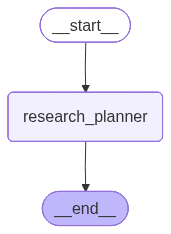

In [56]:
from IPython.display import Image, display

builder = StateGraph(ResearchState)
builder.add_node("research_planner", research_planner)
builder.add_edge(START, "research_planner")
builder.add_edge("research_planner", END)

mini_graph = builder.compile()
display(Image(mini_graph.get_graph().draw_mermaid_png()))

In [57]:
DEMO_TOPIC = "The Current State of AI Coding Assistants in 2026: Tools, Benchmarks, and Adoption"

result = mini_graph.invoke({
    "topic": DEMO_TOPIC,
    "research_plan": None,
    "search_results": [],
    "analysis": None,
    "charts": [],
    "report_sections": {},
    "final_report_html": "",
    "iteration_count": 0,
    "max_iterations": 3,
    "status": "",
})

plan = result["research_plan"]
print(f"Title: {plan.title}")
print(f"\nSections ({len(plan.sections)}):")
for s in plan.sections:
    print(f"  • {s.title} ({len(s.search_queries)} queries)")
print(f"\nSuggested charts: {plan.suggested_charts}")

Title: The Current State of AI Coding Assistants in 2026: Tools, Benchmarks, and Adoption

Sections (6):
  • 1) Market Overview and Product Landscape (3 queries)
  • 2) Benchmarking Performance and Evaluation Methods (3 queries)
  • 3) Real-World Developer Adoption and Usage Patterns (3 queries)
  • 4) Impact on Productivity, Quality, and Developer Experience (3 queries)
  • 5) Governance, Security, and Enterprise Adoption Constraints (3 queries)
  • 6) Outlook: Competitive Dynamics and Strategic Implications (3 queries)

Suggested charts: ['Market landscape matrix of leading tools by workflow, deployment model, and differentiation', 'Benchmark comparison table or bar chart across major coding benchmarks and task types', 'Adoption funnel or stacked bar chart showing individual vs. team vs. enterprise usage', 'Impact dashboard with before/after productivity, quality, and satisfaction metrics']


---
## 3. Web Research Node: Tavily Search

This node uses the [Tavily](https://tavily.com/) search API to gather web results for each section's queries. The results accumulate in `search_results` via the `operator.add` reducer.

> **Note**: We use the Tavily client directly here for transparency. LangGraph also supports a `ToolNode` pattern — we'll mention it at the end.

In [58]:
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

MAX_QUERIES_PER_SECTION = 2
MAX_RESULTS_PER_QUERY = 3


def web_researcher(state: ResearchState) -> dict:
    """Search the web for each section's queries."""
    plan = state["research_plan"]
    new_results = []

    for section in plan.sections:
        for query in section.search_queries[:MAX_QUERIES_PER_SECTION]:
            try:
                response = tavily_client.search(
                    query=query,
                    max_results=MAX_RESULTS_PER_QUERY,
                    search_depth="basic",
                )
                for r in response.get("results", []):
                    new_results.append(SearchResult(
                        query=query,
                        url=r.get("url", ""),
                        title=r.get("title", ""),
                        content=r.get("content", ""),
                        section=section.title,
                    ))
            except Exception as e:
                print(f"  ⚠ Search failed for '{query}': {e}")

    print(f"  ✓ Gathered {len(new_results)} results")
    return {"search_results": new_results, "status": "researched"}

### Test: Planner → Researcher (2-node graph)

Let's wire the first two nodes together and see the search results accumulate.

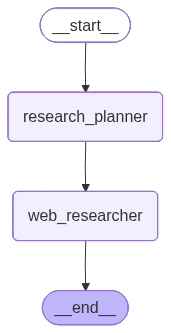

In [59]:
builder = StateGraph(ResearchState)
builder.add_node("research_planner", research_planner)
builder.add_node("web_researcher", web_researcher)
builder.add_edge(START, "research_planner")
builder.add_edge("research_planner", "web_researcher")
builder.add_edge("web_researcher", END)

two_node = builder.compile()
display(Image(two_node.get_graph().draw_mermaid_png()))

In [60]:
result = two_node.invoke({
    "topic": DEMO_TOPIC,
    "research_plan": None,
    "search_results": [],
    "analysis": None,
    "charts": [],
    "report_sections": {},
    "final_report_html": "",
    "iteration_count": 0,
    "max_iterations": 3,
    "status": "",
})

print(f"Total search results: {len(result['search_results'])}")
for r in result["search_results"][:3]:
    print(f"  [{r.section}] {r.title[:60]}...")

  ✓ Gathered 36 results
Total search results: 36
  [1. Market Overview and Category Definition] The best AI-coding tools in 2026 - LeadDev...
  [1. Market Overview and Category Definition] Best AI Coding Assistants 2026: Top 10 Tools Tested & Ranked...
  [1. Market Overview and Category Definition] AI Tooling for Software Engineers in 2026 - The Pragmatic En...


---
## 4. Conditional Routing: Research Sufficiency Loop

What if the researcher doesn't find enough results? We add a **conditional edge** that checks result count and loops back if needed.

The routing function returns the **name of the next node** — LangGraph handles the rest.

In [61]:
from typing import Literal

def check_research_sufficiency(state: ResearchState) -> Literal["data_analyst", "web_researcher"]:
    """Route: enough data → analyst, too few results → research more."""
    results_count = len(state.get("search_results", []))
    iteration = state.get("iteration_count", 0)
    max_iter = state.get("max_iterations", 3)

    if results_count < 5 and iteration < max_iter:
        print(f"  ↻ Only {results_count} results — looping back for more")
        return "web_researcher"
    return "data_analyst"

We'll test this with a placeholder analyst node for now:

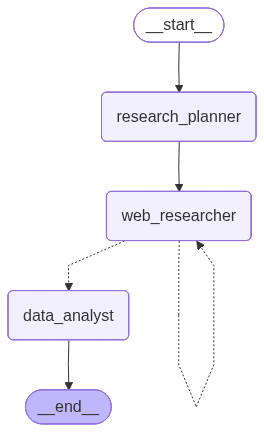

In [62]:
def placeholder_analyst(state):
    print(f"  ✓ Analyst received {len(state['search_results'])} results")
    return {"status": "analyzed"}

builder = StateGraph(ResearchState)
builder.add_node("research_planner", research_planner)
builder.add_node("web_researcher", web_researcher)
builder.add_node("data_analyst", placeholder_analyst)

builder.add_edge(START, "research_planner")
builder.add_edge("research_planner", "web_researcher")
builder.add_conditional_edges(
    "web_researcher",
    check_research_sufficiency,
    ["data_analyst", "web_researcher"],  # valid destinations
)
builder.add_edge("data_analyst", END)

loop_graph = builder.compile()
display(Image(loop_graph.get_graph().draw_mermaid_png()))

Notice the **loop** in the graph visualization! The `web_researcher` can route back to itself.

---
## 5. Data Analysis + Chart Generation

### The Analyst: Structured Data Extraction

The analyst uses `with_structured_output(DataAnalysis)` to extract quantitative data, chart specs, and a summary table from the raw search results.

In [63]:
ANALYST_SYSTEM_PROMPT = """\
You are a data analyst who extracts quantitative insights from research.

Given raw search results, produce:
1. key_findings: 5-10 concise bullet-point findings
2. data_points: list of dicts with quantitative facts
3. chart_specs: 2-4 chart specifications with REAL data from the research.
   Chart types: bar, horizontal_bar, line, pie, scatter, heatmap
   Data formats:
   - bar/horizontal_bar/line: {"labels": [...], "values": [...]}
   - pie: {"labels": [...], "sizes": [...]}
   - scatter: {"x": [...], "y": [...]}
   - heatmap: {"labels": [...], "matrix": [[...]]}
4. summary_table: {"columns": [...], "rows": [[...], ...]}

Use ONLY data from the search results. Assign each chart a 'section' field.
"""


def data_analyst(state: ResearchState) -> dict:
    """Analyse search results → structured data for charts/tables."""
    structured_llm = llm.with_structured_output(DataAnalysis, method="function_calling")

    # Group results by section
    by_section = {}
    for r in state["search_results"]:
        by_section.setdefault(r.section, []).append(f"[{r.title}]({r.url})\n{r.content}")

    digest = "\n\n".join(
        f"## {sec}\n" + "\n---\n".join(snippets)
        for sec, snippets in by_section.items()
    )

    analysis = structured_llm.invoke([
        {"role": "system", "content": ANALYST_SYSTEM_PROMPT},
        {"role": "user", "content": f"Analyse:\n\n{digest}"},
    ])

    print(f"  ✓ {len(analysis.key_findings)} findings, {len(analysis.chart_specs)} charts")
    return {"analysis": analysis, "status": "analyzed"}


### The Chart Generator: A Pure Python Node

This node is **not** an LLM call — it's pure matplotlib. The LLM specified *what* to chart (via `ChartSpec`); this node handles *how*.

This demonstrates that LangGraph nodes can be **any Python function**, not just LLM wrappers.

In [64]:
import base64, io
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
COLORS = ["#2c3e50", "#3498db", "#e74c3c", "#2ecc71", "#f39c12",
          "#9b59b6", "#1abc9c", "#e67e22", "#34495e", "#16a085"]


def _fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    buf.seek(0)
    encoded = base64.b64encode(buf.read()).decode("utf-8")
    plt.close(fig)
    return encoded


def _render_chart(spec: ChartSpec):
    """Dispatch to the right matplotlib renderer."""
    fig, ax = plt.subplots(figsize=(10, 5))
    ct = spec.chart_type

    if ct == "bar":
        labels, values = spec.data["labels"], spec.data["values"]
        bars = ax.bar(labels, values, color=COLORS[:len(labels)])
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f"{val}", ha="center", va="bottom", fontsize=9)
        plt.xticks(rotation=30, ha="right")

    elif ct == "horizontal_bar":
        labels, values = spec.data["labels"], spec.data["values"]
        ax.barh(range(len(labels)), values, color=COLORS[:len(labels)])
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels)

    elif ct == "line":
        labels, values = spec.data["labels"], spec.data["values"]
        ax.plot(labels, values, marker="o", linewidth=2, color=COLORS[0])
        ax.fill_between(labels, values, alpha=0.1, color=COLORS[0])
        plt.xticks(rotation=30, ha="right")

    elif ct == "pie":
        plt.close(fig)
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.pie(spec.data["sizes"], labels=spec.data["labels"],
               autopct="%1.1f%%", startangle=140, colors=COLORS[:len(spec.data["labels"])])

    elif ct == "scatter":
        ax.scatter(spec.data["x"], spec.data["y"],
                   color=COLORS[0], s=80, alpha=0.7, edgecolors="white")

    elif ct == "heatmap":
        import numpy as np
        plt.close(fig)
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(np.array(spec.data["matrix"]), annot=True, fmt=".1f",
                    xticklabels=spec.data["labels"], yticklabels=spec.data["labels"],
                    cmap="YlOrRd", ax=ax)
    else:
        plt.close(fig)
        return None

    ax.set_title(spec.title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    return fig


def chart_generator(state: ResearchState) -> dict:
    """Generate matplotlib charts from ChartSpec list — no LLM needed."""
    analysis = state.get("analysis")
    if not analysis or not analysis.chart_specs:
        return {"charts": [], "status": "charts_generated"}

    charts = []
    for spec in analysis.chart_specs:
        try:
            fig = _render_chart(spec)
            if fig:
                charts.append(ChartData(
                    title=spec.title,
                    base64_png=_fig_to_base64(fig),
                    description=spec.description,
                    section=spec.section,
                ))
                print(f"  ✓ Chart: {spec.title}")
        except Exception as e:
            print(f"  ⚠ Chart failed '{spec.title}': {e}")
            plt.close("all")

    return {"charts": charts, "status": "charts_generated"}

---
## 7. Report Writer + Quality Loop

This is the most complex node — it does two things:
1. **Writes** each report section using the gathered research + analysis
2. **Self-reviews** quality using `with_structured_output(QualityReview)`

The `QualityReview.route_to` field drives a **multi-destination conditional edge**:
- `"compiler"` → report is ready, proceed to final assembly
- `"web_researcher"` → sections need more source material
- `"data_analyst"` → needs more quantitative analysis

In [65]:
WRITER_SYSTEM_PROMPT = """\
You are a professional report writer producing publication-quality research reports.
Write the requested section using the provided research material.
- Clear, authoritative prose for a professional audience
- Cite specific data points and sources
- Use markdown formatting (headers, bold, bullets)
- Each section: 200-400 words
"""

REVIEWER_SYSTEM_PROMPT = """\
You are a quality reviewer for research reports. Assess completeness.
Route to:
- "compiler" if the report is ready for final assembly
- "web_researcher" if sections need more source material
- "data_analyst" if more quantitative analysis or charts are needed
Be pragmatic — thorough and professional is enough, perfection isn't required.
"""


def report_writer(state: ResearchState) -> dict:
    """Write report sections, then self-review quality."""
    writing_llm = init_chat_model("openai:gpt-5.4-mini", temperature=0.3)
    review_llm = llm.with_structured_output(QualityReview, method="function_calling")
    plan = state["research_plan"]
    analysis = state.get("analysis")

    # Group search results by section
    by_section = {}
    for r in state["search_results"]:
        by_section.setdefault(r.section, []).append(f"**{r.title}** ({r.url})\n{r.content}")

    analysis_ctx = ""
    if analysis:
        analysis_ctx = "\n\nKey findings:\n" + "\n".join(f"- {f}" for f in analysis.key_findings)

    # Phase 1: Write sections
    sections = {}

    # Executive summary
    resp = writing_llm.invoke([
        {"role": "system", "content": WRITER_SYSTEM_PROMPT},
        {"role": "user", "content": f"Write an executive summary for '{plan.title}'.\n"
         f"Focus on: {plan.executive_summary_prompt}{analysis_ctx}"},
    ])
    sections["Executive Summary"] = resp.content

    # Content sections
    for sec in plan.sections:
        sources = "\n---\n".join(by_section.get(sec.title, ["No results available."]))
        resp = writing_llm.invoke([
            {"role": "system", "content": WRITER_SYSTEM_PROMPT},
            {"role": "user", "content": f"Write section '{sec.title}' for '{plan.title}'.\n"
             f"Goal: {sec.description}\n\nSources:\n{sources}{analysis_ctx}"},
        ])
        sections[sec.title] = resp.content
        print(f"  ✓ Wrote: {sec.title}")

    # Phase 2: Self-review
    preview = "\n\n".join(f"### {t}\n{c[:300]}..." for t, c in sections.items())
    review = review_llm.invoke([
        {"role": "system", "content": REVIEWER_SYSTEM_PROMPT},
        {"role": "user", "content": f"Review:\n{preview}\n\nCharts: {len(state.get('charts', []))}, "},
    ])

    print(f"  ✓ Quality: complete={review.is_complete}, route={review.route_to}")
    return {
        "report_sections": sections,
        "status": review.route_to,
        "iteration_count": state["iteration_count"] + 1,
    }


### Quality Routing Function

This conditional edge routes to **three possible destinations** based on the self-review. It also includes a safety valve: `max_iterations` prevents infinite loops.

In [66]:
def check_quality(state: ResearchState) -> Literal["report_compiler", "web_researcher", "data_analyst"]:
    """Route based on quality review — with max_iterations safety."""
    if state.get("iteration_count", 0) >= state.get("max_iterations", 3):
        print(f"  ⚑ Max iterations reached — finishing")
        return "report_compiler"

    status = state.get("status", "compiler")
    route = {
        "compiler": "report_compiler",
        "web_researcher": "web_researcher",
        "data_analyst": "data_analyst",
    }.get(status, "report_compiler")

    if route != "report_compiler":
        print(f"  ↻ Quality loop → {route}")
    return route

---
## 8. Report Compiler: Jinja2 → HTML

The final node assembles everything into a self-contained HTML report using a Jinja2 template. All images are embedded as base64 data URIs — the HTML file has zero external dependencies.

In [72]:
import datetime
from pathlib import Path
import jinja2
import pandas as pd


def _build_summary_table_html(analysis):
    if not analysis or not analysis.summary_table:
        return ""
    cols = analysis.summary_table.get("columns", [])
    rows = analysis.summary_table.get("rows", [])
    if not cols or not rows:
        return ""
    df = pd.DataFrame(rows, columns=cols)
    return (
        df.style
        .set_table_styles([
            {"selector": "th", "props": [("background-color", "#2c3e50"), ("color", "white"),
                                          ("padding", "10px 14px")]},
            {"selector": "td", "props": [("padding", "8px 14px"), ("border-bottom", "1px solid #dee2e6")]},
            {"selector": "tr:nth-child(even)", "props": [("background-color", "#f8f9fa")]},
        ])
        .hide(axis="index")
        .to_html()
    )


def report_compiler(state: ResearchState) -> dict:
    """Assemble the final HTML report from all gathered materials."""
    plan = state["research_plan"]
    sections = state.get("report_sections", {})
    charts = state.get("charts", [])
    analysis = state.get("analysis")

    # Group charts by section
    charts_by_section = {}
    for c in charts:
        charts_by_section.setdefault(c.section, []).append(c)

    template_sections = [
        {"title": t, "content": c, "charts": charts_by_section.get(t, [])}
        for t, c in sections.items()
    ]

    # Unique sources
    seen = set()
    sources = []
    for r in state.get("search_results", []):
        if r.url and r.url not in seen:
            seen.add(r.url)
            sources.append({"title": r.title, "url": r.url})

    # Load template
    template_dir = Path("../scripts/research_report/templates").resolve()
    if not template_dir.exists():
        template_dir = Path("scripts/research_report/templates").resolve()

    env = jinja2.Environment(
        loader=jinja2.FileSystemLoader(str(template_dir)),
        autoescape=jinja2.select_autoescape(["html"]),
    )
    template = env.get_template("report.html")

    html = template.render(
        title=plan.title,
        topic=state["topic"],
        generated_date=datetime.date.today().isoformat(),
        executive_summary=sections.get("Executive Summary", ""),
        summary_table=_build_summary_table_html(analysis),
        sections=template_sections,
        sources=sources,
        key_findings=analysis.key_findings if analysis else [],
    )

    # Save
    output_dir = Path("../output").resolve()
    if not output_dir.exists():
        output_dir = Path("output").resolve()
    output_dir.mkdir(parents=True, exist_ok=True)

    safe_name = "".join(c if c.isalnum() or c in "- " else "" for c in plan.title)
    safe_name = safe_name.strip().replace(" ", "-")[:80]
    html_path = output_dir / f"{safe_name}.html"
    html_path.write_text(html, encoding="utf-8")
    print(f"  ✓ Report saved: {html_path}")

    return {"final_report_html": html, "status": "complete"}

---
## 9. The Full Graph: Wiring It All Together

Now we assemble the complete graph with:
- **Parallel fan-out**: planner → researcher
- **Conditional loop**: researcher → check sufficiency → loop or continue
- **Quality loop**: report_writer → check quality → compiler, researcher, or analyst

This is the full architecture in ~30 lines of wiring code:

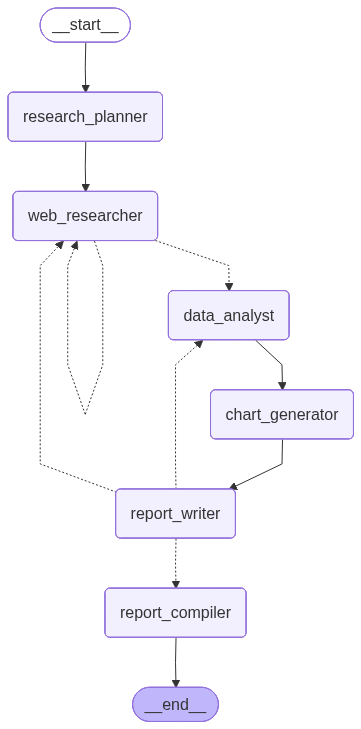

In [73]:
builder = StateGraph(ResearchState)

# Add all nodes
builder.add_node("research_planner", research_planner)
builder.add_node("web_researcher", web_researcher)
builder.add_node("data_analyst", data_analyst)
builder.add_node("chart_generator", chart_generator)
builder.add_node("report_writer", report_writer)
builder.add_node("report_compiler", report_compiler)

# START → planner
builder.add_edge(START, "research_planner")

# Planner fans out to TWO nodes in parallel
builder.add_edge("research_planner", "web_researcher")

# Researcher → conditional: enough data or loop?
builder.add_conditional_edges(
    "web_researcher",
    check_research_sufficiency,
    ["data_analyst", "web_researcher"],
)


# Linear: analyst → charts → writer
builder.add_edge("data_analyst", "chart_generator")
builder.add_edge("chart_generator", "report_writer")

# Writer → quality routing (3 possible destinations)
builder.add_conditional_edges(
    "report_writer",
    check_quality,
    ["report_compiler", "web_researcher", "data_analyst"],
)

# Compiler → END
builder.add_edge("report_compiler", END)

# Compile!
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### Run the Full Pipeline!

Let's generate a complete research report. This will:
1. Plan the research structure
2. Search the web
3. Analyse data and generate charts
4. Write and self-review the report
5. Compile into a self-contained HTML file

In [74]:
result = graph.invoke({
    "topic": DEMO_TOPIC,
    "research_plan": None,
    "search_results": [],
    "analysis": None,
    "charts": [],
    "report_sections": {},
    "final_report_html": "",
    "iteration_count": 0,
    "max_iterations": 2,
    "status": "",
})

print(f"\n{'='*50}")
print(f"Status: {result['status']}")
print(f"Sections: {list(result['report_sections'].keys())}")
print(f"Charts: {len(result['charts'])}")
print(f"Search results: {len(result['search_results'])}")
print(f"Iterations: {result['iteration_count']}")

  ✓ Gathered 36 results
  ✓ 10 findings, 4 charts
  ⚠ Chart failed 'Developer Adoption and Parallel Tool Use': 'labels'
  ⚠ Chart failed 'Enterprise Adoption and AI-Authored Code Share': 'labels'
  ⚠ Chart failed 'Benchmark and Productivity Claims by Tool': 'labels'
  ⚠ Chart failed 'Security Risk Perception Among Organizations': 'sizes'
  ✓ Wrote: 1) Market Overview and Product Landscape
  ✓ Wrote: 2) Core Capabilities and Workflow Integration
  ✓ Wrote: 3) Benchmarks, Evaluation Methods, and Model Performance
  ✓ Wrote: 4) Adoption Trends Across Developers and Enterprises
  ✓ Wrote: 5) Risks, Limitations, and Operational Considerations
  ✓ Wrote: 6) Outlook and Strategic Implications
  ✓ Quality: complete=False, route=web_researcher
  ↻ Quality loop → web_researcher
  ✓ Gathered 36 results
  ✓ 10 findings, 4 charts
  ⚠ Chart failed 'Developer AI Coding Tool Usage Indicators': 'labels'
  ⚠ Chart failed 'Reported Adoption and AI-Authored Code Metrics': 'labels'
  ⚠ Chart failed 'Benchm

### View the Report Inline

In [75]:
from IPython.display import HTML

# Display the full report right here in the notebook
HTML(result["final_report_html"])

### View Individual Charts

In [76]:
from IPython.display import display, Image as IPImage

for chart in result.get("charts", []):
    print(f"\n📊 {chart.title}")
    print(f"   {chart.description}")
    display(IPImage(data=base64.b64decode(chart.base64_png)))

---
## 10. Try Your Own Topic!

Change the topic below and re-run to generate a report on anything:

In [ ]:
MY_TOPIC = "Comparing Python Web Frameworks: Django, Flask, and FastAPI"  # ← change this!

my_result = graph.invoke({
    "topic": MY_TOPIC,
    "research_plan": None,
    "search_results": [],
    "analysis": None,
    "charts": [],
    "report_sections": {},
    "final_report_html": "",
    "iteration_count": 0,
    "max_iterations": 2,
    "status": "",
})

HTML(my_result["final_report_html"])

---
## Summary

We built a complete multi-agent research pipeline using LangGraph:

| Node | LangGraph Concept |
|------|-------------------|
| `research_planner` | Structured output with Pydantic + `with_structured_output()` |
| `web_researcher` | Tool-based web search, state accumulation |
| `check_sufficiency` | Conditional edges with loop-back |
| `data_analyst` | Structured analysis, reducers for accumulation |
| `chart_generator` | Pure Python node (no LLM), matplotlib rendering |
| `report_writer` | Quality self-review with structured output |
| `check_quality` | Multi-destination conditional routing + safety valve |
| `report_compiler` | Jinja2 templating, self-contained HTML output |

### Key Takeaways

1. **Reducers** (`Annotated[list, operator.add]`) control how state keys accumulate vs. overwrite
2. **Structured output** (`with_structured_output(Pydantic)`) gives you type-safe LLM responses
3. **Conditional edges** enable loops, routing, and quality control
4. **Parallel fan-out** lets independent nodes run simultaneously
5. **Any Python function** can be a node — not just LLM calls
6. **`max_iterations`** prevents infinite loops in production

### Next Steps

- Add **memory** with `InMemorySaver` for multi-turn research sessions
- Use `ToolNode` + `tools_condition` for a more agentic search pattern
- Add a **human-in-the-loop** `interrupt()` before the compiler for manual review
- Deploy with **LangGraph Studio** for visual debugging